## 1. Install dependencies

In [14]:
!pip install tensorflow roboflow ultralytics openai-whisper elevenlabs sounddevice scipy pillow matplotlib



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports

In [15]:
import os
import re
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt

import whisper
from ultralytics import YOLO
from roboflow import Roboflow

from elevenlabs.client import ElevenLabs
from elevenlabs import save as save_audio

import sounddevice as sd
from scipy.io.wavfile import write as write_wav

from IPython.display import Audio, display
import tkinter as tk
from tkinter import filedialog



## 3. Config

In [ ]:
IMG_SIZE = (224, 224)
CLASS_NAMES = ["autoroute", "urbaine", "rurale"]  # must match the order used during training

LOCAL_MODEL_PATH = "oldroad_classifier.keras"

ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")
ELEVENLABS_API_KEY = os.getenv("ELEVENLABS_API_KEY")

# --- Roboflow off-road model ---
OFFROAD_WORKSPACE = "sri-lab"
OFFROAD_PROJECT = "road-surface-classification-lgxl1"
OFFROAD_VERSION = 1
UNPAVED_CLASS_NAMES = {"Unpaved"}
OFFROAD_CONFIDENCE_THRESHOLD = 0.5

# --- Roboflow damage model
DAMAGE_WORKSPACE = "roaddamage-msfnj"
DAMAGE_PROJECT = "road-damage-ww8ex"
DAMAGE_VERSION = 1
DAMAGE_CONFIDENCE_THRESHOLD = 0.5

# --- Traffic sign model (GitHub)
SIGN_REPO_URL = "https://github.com/bhaskrr/traffic-sign-detection-using-yolov11.git"
SIGN_REPO_LOCAL_DIR = "traffic_sign_repo"
SIGN_WEIGHTS_FILENAME = "traffic_sign_detector.pt"  # Fixed: real filename in repo
SIGN_CONFIDENCE_THRESHOLD = 0.5
IGNORED_SIGN_CLASSES = {"all"}  # known bogus class from the source dataset export

# --- ElevenLabs voice ---
# Default voice_id below ("George") works fine for French via the multilingual model +
# language_code — but browse elevenlabs.io's Voice Library for one you actually like,
# or run elevenlabs_client.voices.search() to list what's available on your account.
ELEVENLABS_VOICE_ID = "JBFqnCBsd6RMkjVDRZzb"
ELEVENLABS_MODEL_ID = "eleven_multilingual_v2"

# --- Gemini (conversational brain + command understanding) ---
# Free key: aistudio.google.com -> "Get API key" -> create/pick a project -> copy the key
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
LLM_MODEL = "gemini-1.5-flash"  # free-tier eligible, generous daily quota, good for short exchanges


## 4. Load the trained road-type classifier

In [17]:
if not os.path.exists(LOCAL_MODEL_PATH):
    raise FileNotFoundError(
        f"{LOCAL_MODEL_PATH} not found. Download it from your Kaggle notebook's Output tab "
        f"and place it next to this notebook."
    )

road_classifier = tf.keras.models.load_model(LOCAL_MODEL_PATH)
print("Road-type classifier loaded.")


Road-type classifier loaded.


## 5. Load the off-road (Roboflow) model

In [18]:
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

offroad_project = rf.workspace(OFFROAD_WORKSPACE).project(OFFROAD_PROJECT)
offroad_model = offroad_project.version(OFFROAD_VERSION).model
print("Off-road model loaded.")


loading Roboflow workspace...
loading Roboflow project...
Off-road model loaded.


In [31]:
def detect_offroad(image_path):
    result = offroad_model.predict(image_path).json()
    predictions = result.get("predictions", [])
    if not predictions:
        return False, 0.0

    top = predictions[0] if isinstance(predictions, list) else predictions
    predicted_class = top.get("class") or top.get("top", "")
    confidence = top.get("confidence", 0.0)

    is_offroad = predicted_class in UNPAVED_CLASS_NAMES and confidence >= OFFROAD_CONFIDENCE_THRESHOLD
    return is_offroad, confidence

## 6. Load the damage (Roboflow) model

In [20]:
damage_project = rf.workspace(DAMAGE_WORKSPACE).project(DAMAGE_PROJECT)
damage_model_rf = damage_project.version(DAMAGE_VERSION).model
print("Damage model loaded.")


loading Roboflow workspace...
loading Roboflow project...
Damage model loaded.


In [22]:
def detect_damage(image_path):
    result = damage_model_rf.predict(image_path).json()
    detections = result.get("predictions", [])
    parsed = [{"class": d.get("class"), "confidence": d.get("confidence", 0.0)} for d in detections]
    max_confidence = max((d["confidence"] for d in parsed), default=0.0)
    is_damaged = len(parsed) > 0
    return is_damaged, max_confidence, parsed


## 7. Load the traffic sign model (GitHub)

In [23]:
if not os.path.exists(SIGN_REPO_LOCAL_DIR):
    os.system(f"git clone {SIGN_REPO_URL} {SIGN_REPO_LOCAL_DIR}")

model_dir = os.path.join(SIGN_REPO_LOCAL_DIR, "model")
print("Files in the model/ folder:")
for f in os.listdir(model_dir):
    print(" ", f)


Files in the model/ folder:
  traffic_sign_detector.pt


In [24]:
sign_weights_path = os.path.join(model_dir, SIGN_WEIGHTS_FILENAME)
sign_model = YOLO(sign_weights_path)
print("Traffic sign model loaded. Classes:", sign_model.names)


Traffic sign model loaded. Classes: {0: 'Green Light', 1: 'Red Light', 2: 'Speed Limit 10', 3: 'Speed Limit 100', 4: 'Speed Limit 110', 5: 'Speed Limit 120', 6: 'Speed Limit 20', 7: 'Speed Limit 30', 8: 'Speed Limit 40', 9: 'Speed Limit 50', 10: 'Speed Limit 60', 11: 'Speed Limit 70', 12: 'Speed Limit 80', 13: 'Speed Limit 90', 14: 'Stop'}


In [25]:
def detect_traffic_signs(image_path):
    results = sign_model.predict(image_path, verbose=False)
    detections = []
    for r in results:
        for box in r.boxes:
            conf = float(box.conf[0])
            cls_name = sign_model.names[int(box.cls[0])]
            if cls_name in IGNORED_SIGN_CLASSES or conf < SIGN_CONFIDENCE_THRESHOLD:
                continue
            detections.append({"class": cls_name, "confidence": conf})
    return detections


## 8. Speed logic — road type + damage + sign overrides

In [27]:
BASE_SPEED_BY_ROAD_TYPE = {
    "autoroute": 120,
    "urbaine": 60,
    "rurale": 100,
    "off-road": 70,
}
DAMAGE_SPEED_REDUCTION = 0.30

def get_base_speed(road_type, is_damaged):
    speed = BASE_SPEED_BY_ROAD_TYPE[road_type]
    if is_damaged:
        speed = speed * (1 - DAMAGE_SPEED_REDUCTION)
    return round(speed, 1)


def apply_sign_overrides(current_speed, detected_signs):
    for sign in detected_signs:
        if sign["class"] in ("Stop", "Red Light"):
            return 0, f"{sign['class']} detected — mandatory stop"

    final_speed = current_speed
    override_reason = None
    for sign in detected_signs:
        match = re.search(r"Speed Limit (\d+)", sign["class"])
        if match:
            posted_limit = int(match.group(1))
            if posted_limit < final_speed:
                final_speed = posted_limit
                override_reason = f"Capped to posted limit: {posted_limit} km/h"

    return final_speed, override_reason


## 9. Full combined pipeline

In [28]:
def classify_full(image_path):
    is_offroad, offroad_conf = detect_offroad(image_path)
    if is_offroad:
        road_type = "off-road"
    else:
        img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
        img_array = tf.keras.utils.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0)
        predictions = road_classifier.predict(img_array, verbose=0)
        road_type = CLASS_NAMES[np.argmax(predictions[0])]

    is_damaged, damage_conf, damage_detections = detect_damage(image_path)
    detected_signs = detect_traffic_signs(image_path)

    base_speed = get_base_speed(road_type, is_damaged)
    final_speed, override_reason = apply_sign_overrides(base_speed, detected_signs)

    return {
        "road_type": road_type,
        "damaged": is_damaged,
        "detected_signs": detected_signs,
        "base_speed": base_speed,
        "final_speed_kmh": final_speed,
        "override_reason": override_reason,
    }


## 10. Upload a picture from your laptop and run the full pipeline

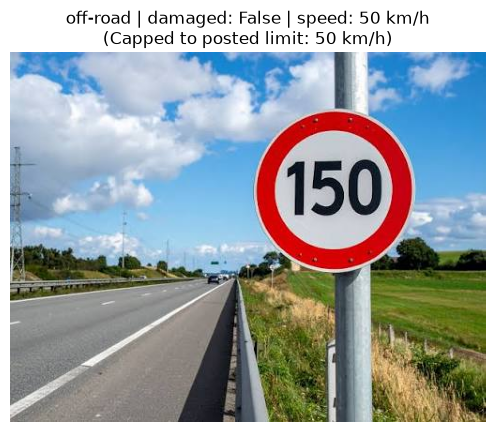

{'road_type': 'off-road', 'damaged': False, 'detected_signs': [{'class': 'Speed Limit 50', 'confidence': 0.950035035610199}], 'base_speed': 70, 'final_speed_kmh': 50, 'override_reason': 'Capped to posted limit: 50 km/h'}


In [32]:
def pick_image_file():
    try:
        root = tk.Tk()
        root.withdraw()
        # Ensure the dialog appears on top
        root.attributes('-topmost', True)
        file_path = filedialog.askopenfilename(
            title="Select a road image",
            filetypes=[("Image files", "*.jpg *.jpeg *.png")]
        )
        root.destroy()
        return file_path
    except Exception as e:
        print(f"Tkinter dialog failed: {e}")
        # Fallback to manual input if dialog fails
        path = input("Enter the full path to the image file: ").strip().strip('"')
        return path if os.path.exists(path) else None


image_path = pick_image_file()

if image_path:
    result = classify_full(image_path)

    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis("off")
    title = f"{result['road_type']} | damaged: {result['damaged']} | speed: {result['final_speed_kmh']} km/h"
    if result["override_reason"]:
        title += f"\n({result['override_reason']})"
    plt.title(title)
    plt.show()

    print(result)
else:
    print("No file selected.")


## 11. Voice assistant — intent parsing, dispatcher, ElevenLabs TTS

In [1]:
whisper_model = whisper.load_model("base")

def transcribe_audio(audio_path, language="fr"):
    # Whisper's default load_audio requires ffmpeg.
    # We load it manually using scipy and convert to float32 to avoid the ffmpeg dependency.
    try:
        from scipy.io.wavfile import read as read_wav
        sr, audio = read_wav(audio_path)
        # Convert to float32 and normalize to [-1.0, 1.0] if it's int16
        if audio.dtype == np.int16:
            audio = audio.astype(np.float32) / 32768.0
        # Whisper expects 16000Hz. record_audio already uses 16000.
        result = whisper_model.transcribe(audio, language=language)
        return result["text"].strip()
    except Exception as e:
        print(f"Transcription failed: {e}")
        return ""


INTENT_PATTERNS = [
    (r"ferme.*fen[êe]tre|close.*window",                        "close_window",             False),
    (r"ouvre.*fen[êe]tre|open.*window",                          "open_window",              False),
    (r"limite.*vitesse|limit.*speed",                            "set_speed_limit",          True),
    (r"r[éèe]gle.*vitesse.*croisi[èe]re|set.*cruise.*speed",     "set_cruise_speed",         True),
    (r"mode [ée]co|eco mode",                                     "enable_eco_mode",          False),
    (r"augmente.*distance|increase.*distance",                    "increase_safety_distance", False),
    (r"diminue.*distance|reduis.*distance|decrease.*distance",    "decrease_safety_distance", False),
    (r"baisse.*vitesse|ralentis|lower.*speed|slow down",          "decrease_speed",           False),
    (r"augmente.*vitesse|acc[ée]l[èe]re|speed up",                "increase_speed",           False),
]


def extract_number(text):
    match = re.search(r"(\d+)", text)
    return int(match.group(1)) if match else None


def parse_intent(text):
    text_lower = text.lower()
    for pattern, intent, needs_number in INTENT_PATTERNS:
        if re.search(pattern, text_lower):
            value = extract_number(text_lower) if needs_number else None
            return {"intent": intent, "value": value, "raw_text": text}
    return {"intent": "unknown", "value": None, "raw_text": text}


def dispatch_command(parsed_intent, vehicle_state):
    intent = parsed_intent["intent"]
    value = parsed_intent["value"]

    if intent == "set_speed_limit" and value is not None:
        vehicle_state["speed_limit_kmh"] = value
    elif intent == "set_cruise_speed" and value is not None:
        vehicle_state["cruise_speed_kmh"] = value
    elif intent == "enable_eco_mode":
        vehicle_state["eco_mode"] = True
    elif intent == "increase_safety_distance":
        vehicle_state["safety_distance_level"] += 1
    elif intent == "decrease_safety_distance":
        vehicle_state["safety_distance_level"] = max(1, vehicle_state["safety_distance_level"] - 1)
    elif intent == "decrease_speed":
        vehicle_state["cruise_speed_kmh"] = max(0, vehicle_state["cruise_speed_kmh"] - 10)
    elif intent == "increase_speed":
        vehicle_state["cruise_speed_kmh"] += 10
    elif intent == "close_window":
        vehicle_state["window_open"] = False
    elif intent == "open_window":
        vehicle_state["window_open"] = True

    return vehicle_state


RESPONSE_TEMPLATES = {
    "close_window":              "D'accord, je ferme la fenêtre.",
    "open_window":                "D'accord, j'ouvre la fenêtre.",
    "set_speed_limit":            "Limite de vitesse réglée à {value} kilomètres heure.",
    "set_cruise_speed":           "Vitesse de croisière réglée à {value} kilomètres heure.",
    "enable_eco_mode":            "Mode éco activé.",
    "increase_safety_distance":   "J'augmente la distance de sécurité.",
    "decrease_safety_distance":   "Je réduis la distance de sécurité.",
    "decrease_speed":             "D'accord, je ralentis.",
    "increase_speed":             "D'accord, j'accélère.",
    "unknown":                    "Désolé, je n'ai pas compris cette commande.",
}


def generate_response_text(parsed_intent):
    template = RESPONSE_TEMPLATES[parsed_intent["intent"]]
    if "{value}" in template and parsed_intent["value"] is not None:
        return template.format(value=parsed_intent["value"])
    return template


elevenlabs_client = ElevenLabs(api_key=ELEVENLABS_API_KEY)

def speak(text, output_path="response.mp3", voice_id=ELEVENLABS_VOICE_ID, language_code="fr"):
    try:
        # Reverting to the correct SDK method for version 1.x+
        audio = elevenlabs_client.text_to_speech.convert(
            text=text,
            voice_id=voice_id,
            model_id=ELEVENLABS_MODEL_ID,
        )
        save_audio(audio, output_path)
        return output_path
    except Exception as e:
        print(f"ElevenLabs TTS failed: {e}")
        return None


NameError: name 'whisper' is not defined

## 12. Record your own voice with your laptop's microphone

In [ ]:
def record_audio(duration=4, samplerate=16000, output_path="mic_recording.wav"):
    try:
        print(f"Recording for {duration} seconds — speak your command now...")
        recording = sd.rec(int(duration * samplerate), samplerate=samplerate, channels=1, dtype='int16')
        sd.wait()
        write_wav(output_path, samplerate, recording)
        print(f"Recording saved to {output_path}")
        return output_path
    except Exception as e:
        print(f"Audio recording failed: {e}")
        return None


vehicle_state = {
    "cruise_speed_kmh": 50,
    "speed_limit_kmh": None,
    "eco_mode": False,
    "safety_distance_level": 2,
    "window_open": True,
}

audio_path = record_audio(duration=4)

if audio_path:
    text = transcribe_audio(audio_path)
    print(f"\nWhisper heard: {text!r}")

    parsed = parse_intent(text)
    print(f"Parsed intent: {parsed}")

    vehicle_state = dispatch_command(parsed, vehicle_state)
    response_text = generate_response_text(parsed)
    print(f"Response: {response_text}")

    response_audio = speak(response_text)
    if response_audio:
        display(Audio(response_audio, autoplay=True))

    print("\nUpdated vehicle state:", vehicle_state)
else:
    print("Skipping voice interaction because recording failed.")


## 13. Speed-change announcements (tie the image pipeline to the voice assistant)

In [ ]:
SPEED_SUGGESTION_TEMPLATES = {
    "autoroute": "Autoroute détectée. Vitesse suggérée : {speed} kilomètres heure.",
    "urbaine":   "Zone urbaine détectée. Vitesse suggérée : {speed} kilomètres heure.",
    "rurale":    "Route rurale détectée. Vitesse suggérée : {speed} kilomètres heure.",
    "off-road":  "Terrain hors route détecté. Vitesse suggérée : {speed} kilomètres heure.",
}

_last_announced_speed = {"value": None}

def announce_speed_suggestion(road_type, suggested_speed, override_reason=None):
    if suggested_speed == _last_announced_speed["value"]:
        return None

    _last_announced_speed["value"] = suggested_speed

    if override_reason:
        text = f"{override_reason}. Vitesse suggérée : {suggested_speed} kilomètres heure."
    else:
        template = SPEED_SUGGESTION_TEMPLATES.get(road_type, "Vitesse suggérée : {speed} kilomètres heure.")
        text = template.format(speed=suggested_speed)

    audio_path = speak(text, output_path="speed_announcement.mp3")
    return text, audio_path


if "result" in dir():
    announcement = announce_speed_suggestion(result["road_type"], result["final_speed_kmh"], result["override_reason"])
    if announcement:
        text, audio_path = announcement
        print(f"Assistant says: {text}")
        if audio_path:
            display(Audio(audio_path, autoplay=True))
    else:
        print("Assistant stays silent (speed unchanged)")
